# 數位控制系統第一章：導論（教學版 Notebook）

本 Notebook 是 `chp1.md` 教材的教學版，額外補充：
- 每個第一次出現的 MATLAB / Octave 函數（`tf`, `ss`, `step`, `feedback`, `series`, ...）的逐步解說
- MATLAB 向量、矩陣、分號等基礎語法解釋
- 公式 → 程式碼的逐項對照
- 可直接執行的程式碼範例與階躍響應視覺化

建議搭配 `chp1.md`（完整理論、推導與符號定義）與 `chp1.m`（精簡可執行版）一起閱讀。

---

## 🔧 環境設定

在 Octave Jupyter Notebook 中繪圖，需要：
1. 使用 `graphics_toolkit('gnuplot')` 讓圖表能內嵌顯示
2. 載入 `control` 套件（提供 `tf`, `ss`, `step`, `feedback` 等控制工具函數）
3. 設定中文字型以避免亂碼

> 若你是在標準 MATLAB（非 Octave）環境執行，`pkg load control` 這一行會報錯，直接刪除或註解掉即可 —— MATLAB 內建 Control System Toolbox，不需要額外載入套件。

In [25]:
%plot --format svg
% 上面這行是 Octave Jupyter kernel 的「magic」語法（必須放在 cell 第一行），
% 讓圖表以 SVG 格式內嵌顯示，SVG 對中文字型的支援較好，可避免圖表中的中文標題/座標軸文字亂碼。

warning('off', 'Octave:graphics-toolkit');
graphics_toolkit('gnuplot');
clear; clc;
pkg load control;   % 若在 MATLAB 中執行，請刪除或註解此行

set(0, 'DefaultTextFontName', 'Microsoft JhengHei');
set(0, 'DefaultAxesFontName', 'Microsoft JhengHei');

## 📖 開始之前：幾個 MATLAB / Octave 基礎語法

在看程式碼之前，先弄懂幾個貫穿全篇的基本符號，之後遇到就不用再猜：

| 語法 | 意義 | 範例 |
|---|---|---|
| `;`（在敘述結尾） | 抑制該行結果在 Command Window 顯示。不寫分號的話，MATLAB/Octave 會把運算結果印出來 | `J = 10;` 不會印出任何東西；`J = 10`（沒有分號）則會印出 `J = 10` |
| `;`（在 `[...]` 內部） | **換到矩陣的下一列**，和上面「抑制輸出」是同一個符號、但用途完全不同 | `[0 1; 0 -2]` 是 2×2 矩陣：第一列 `0 1`，第二列 `0 -2` |
| `[ ]` | 建立向量（vector）或矩陣（matrix） | `[1 2 3]` 是一個 1×3 的列向量（row vector） |
| `( )` | 呼叫函數，或索引（取用）向量/矩陣中的元素 | `tf(1, [1 2])` 是呼叫 `tf` 函數；`A(1,2)` 是取 `A` 矩陣第 1 列第 2 行的元素 |
| `s^2` | 次方運算 | 對應數學上的 $s^2$ |
| `a:b:c` | 建立等差向量，從 `a` 開始、每次加 `b`、到 `c` 為止 | `0:0.1:50` 代表 $0, 0.1, 0.2, \dots, 50$ |
| `'字串'` | 字串（也常用來指定畫圖顏色/線型，如 `'r'` 代表紅色） | `step(sys, 'r')` |
| `...` | 續行符號，讓一行程式碼可以斷成多行寫，方便閱讀 | `legend('A', ...\n       'B')` |

## 📖 核心函數介紹：`tf()` 與 `ss()`

在 MATLAB / Octave 的 **Control System Toolbox** 中，最常用的兩個建模函數是 `tf()` 和 `ss()`。

### `tf(num, den)` — 建立轉移函數模型

**語法：** `G = tf(分子係數向量, 分母係數向量)`

轉移函數的一般形式：

$$G(s) = \frac{b_m s^m + b_{m-1} s^{m-1} + \cdots + b_1 s + b_0}{a_n s^n + a_{n-1} s^{n-1} + \cdots + a_1 s + a_0}$$

`num` 和 `den` 就是把 **多項式的係數由高次排到低次** 放進一個向量（陣列）裡。

| 範例 | 數學式 | MATLAB 寫法 | 說明 |
|---|---|---|---|
| 純增益 | $G(s)=5$ | `tf([5],[1])` | 分子=5，分母=1 |
| 一階 | $G(s)=\frac{1}{s+2}$ | `tf([1],[1 2])` | 分母 $s+2$ 的係數=`[1 2]` |
| 二階（本章衛星） | $G(s)=\frac{1}{0.6s^2}$ | `tf([1],[0.6 0 0])` | 分母 $0.6s^2+0s+0$ → `[0.6 0 0]` |

### 公式 → 程式碼：把 $G_p(s)=1/(Js^2)$ 轉成 `tf()`

$$G_p(s) = \frac{1}{Js^2} = \frac{1}{Js^2 + 0\cdot s + 0}$$

`tf(num, den)` 的兩個輸入都是 **多項式係數向量**，由高次排到低次：

```text
num = [1]           → 分子 = 1
den = [J 0 0]        → 分母 = J*s^2 + 0*s + 0
```

| 向量位置 | 對應項 | 值 |
|---|---|---|
| 第 1 個元素 | $s^2$ 係數 | $J$ |
| 第 2 個元素 | $s^1$ 係數 | $0$（沒有 $s$ 項） |
| 第 3 個元素 | $s^0$ 係數（常數項） | $0$ |

也就是說：

```text
1/(Js^2)
    ↓
Js^2 + 0s + 0
    ↓
[J 0 0]
    ↓
tf([1], [J 0 0])
```

### `ss(A, B, C, D)` — 建立狀態空間模型

**語法：** `sys = ss(A, B, C, D)`，對應狀態方程式 $\dot x=Ax+Bu,\ y=Cx+Du$。四個輸入分別是系統矩陣、輸入矩陣、輸出矩陣、直接傳遞矩陣（本章範例 $D$ 皆為 0）。

---

## 一、閉迴路控制系統是什麼？(1.1 Overview)

**開迴路**系統的輸出不會回頭影響輸入；**閉迴路（回授）**系統則會量測輸出、拿輸出跟「想要的結果」比較，用差異去修正輸入。一個最基本的閉迴路系統包含：

```text
期望響應 ──►(+)──► 差異訊號 ──► 補償器 ──► 受控體輸入 ──► 受控體(含致動器) ──► 響應（輸出）
              ▲(-)                                                    │
              └───────────────────── 感測器 ◄──────────────────────────┘
```

| 元件 | 功能 |
|---|---|
| 受控體（Plant） | 真正要被控制的物理系統 |
| 感測器（Sensor） | 量測受控體的實際響應 |
| 差異訊號（誤差） | 期望響應與實際響應之差 |
| 補償器 / 控制器 | 把誤差訊號加工成合適的受控體輸入 |

**線性系統與疊加原理**：輸入 $a_1x_1(t)+a_2x_2(t)$ 若恰好產生輸出 $a_1y_1(t)+a_2y_2(t)$（其中 $x_i\to y_i$ 是個別的輸入輸出關係），系統就是線性的。本書分析設計方法只適用於**線性非時變（linear time-invariant）**系統，這也是本章四個建模範例最終都要化簡成線性微分方程式的原因。

**離散 vs. 連續時間系統**：離散時間系統的訊號只在固定取樣瞬間 $kT$ 改變數值（由差分方程式描述，第 2 章主題）；連續時間系統的訊號隨時間連續變化（由微分方程式描述，本章四個範例皆屬此類）。

---

## 二、數位控制系統架構範例：飛機自動降落系統 (1.2)

以自動飛機降落系統為例：雷達每隔 $T=0.05\,\text{s}$ 量測一次飛機橫向位置 $y(t)$，得到取樣序列 $y(kT)$；數位控制器算出離散橫滾指令 $h(kT)$；**數據保持器**把指令維持在最後收到的值，直到下一個新值送達（$T=0.05\,\text{s}$ 後）才更新。系統中還有風力擾動 $w(t)$ 與雷達雜訊（感測器無法量到絕對精確值）。

一個典型數位控制系統的元件：受控體/致動器（本例為飛機）、感測器（雷達）、A/D 轉換器、數位控制器、D/A 轉換器與數據保持器、以及無法避免的擾動與雜訊。

---

## 三、控制問題與設計流程 (1.3)

**控制問題**：閉迴路操作下，輸出（響應）依誤差訊號調整，控制器須滿足四項準則：

| 準則 | 意義 |
|---|---|
| 干擾抑制 | 輸出應盡量不受風力、雜訊等外部擾動影響 |
| 穩態誤差 | 系統穩定後輸出與期望值的殘留誤差應盡量小 |
| 暫態響應 | 狀態轉換過程的速度、震盪程度應符合要求 |
| 參數敏感度 | 受控體參數變化時系統性能不應劇烈惡化 |

**六大設計步驟**：① 選感測器 ② 選致動器 ③ 建立數學模型 ④ 依模型與準則設計控制器 ⑤ 分析/模擬/實測評估 ⑥ 反覆迭代。

**標準負回授迴路公式**（後續 SMIB 範例與第 5 章會大量使用）：

```text
R(s) ──►(+)──► E(s) ──► Gc(s) ──► M(s) ──► Gp(s) ──► C(s)
        ▲(-)                                          │
        └───────────────── H(s) ◄──────────────────────┘
```

$$
\frac{C(s)}{R(s)} = \frac{G_c(s)G_p(s)}{1+G_c(s)G_p(s)H(s)}
$$

本章第九節會用 MATLAB 的 `feedback()` 函數實際計算這個公式。

---

## 四、衛星系統建模 (1.4)

衛星姿態控制：剛體、無摩擦，根據牛頓第二運動定律的旋轉形式：

$$
J \frac{d^2 \theta(t)}{dt^2} = v(t) \quad\Longrightarrow\quad G_p(s) = \frac{\Theta(s)}{V(s)} = \frac{1}{Js^2}
$$

其中 $\theta(t)$ 為航向角（輸出）、$v(t)$ 為推力器轉矩（輸入）、$J$ 為轉動慣量。這是**無阻尼二階純積分系統**——分母兩個極點都在原點，沒有任何自然阻尼。

**符號定義**：

| 符號 | 意義 | 單位 |
|---|---|---|
| $\theta(t)$ | 衛星航向角 | rad |
| $v(t)$ | 推力器轉矩 | N·m |
| $J$ | 轉動慣量 | kg·m² |

In [26]:
%% 建立衛星系統轉移函數
J = 0.6;                    % 轉動慣量 (kg*m^2)
Gp_sat = tf([1], [J 0 0]);  % Gp(s) = 1/(J*s^2)
Gp_sat


Transfer function 'Gp_sat' from input 'u1' to output ...

         1   
 y1:  -------
      0.6 s^2

Continuous-time model.


**這行程式在做什麼？逐項拆解：**

```text
Gp_sat
↓
用來存放建立好的傳遞函數物件的變數名稱

tf()
↓
建立 Transfer Function（傳遞函數）模型

[1]
↓
分子多項式係數 → 分子 = 1

[J 0 0]
↓
分母多項式係數 → J*s^2 + 0*s + 0
```

**數學 ↔ MATLAB 對照**：

| 數學 | MATLAB |
|---|---|
| $G_p(s)=\dfrac{1}{Js^2}$ | `Gp_sat = tf([1], [J 0 0])` |
| 分母 $Js^2+0s+0$ | 係數向量 `[J 0 0]`（由高次到低次排列） |

---

## 五、伺服馬達與機器人關節建模 (1.5)

直流馬達（電樞控制、磁場恆定、忽略電感 $L_a$）由四個方程式（反電動勢、機械平衡、電磁轉矩、電路電壓）消去中間變數 $i(t), v(t)$ 後，得到二階微分方程式，取拉普拉斯轉換後的轉移函數：

$$
G_p(s) = \frac{\Theta(s)}{E(s)} = \frac{K_T/(JR_a)}{s\left(s+\dfrac{BR_a+K_TK_b}{JR_a}\right)}
$$

這是「積分器串聯一階環節」的結構：$s=0$ 的積分極點（電壓要先變角速度才能變角度），加上一個由摩擦 $B$ 與反電動勢常數 $K_b$ 決定的一階實極點。

**符號定義**：

| 符號 | 意義 | 單位 |
|---|---|---|
| $e(t)$ | 電樞輸入電壓（輸入） | V |
| $R_a$ | 電樞電阻 | Ω |
| $K_b$ | 反電動勢常數 | V·s/rad |
| $K_T$ | 轉矩常數 | N·m/A |
| $J$ | 總轉動慣量 | kg·m² |
| $B$ | 總黏滯摩擦係數 | N·m·s/rad |
| $\theta(t)$ | 馬達轉軸角度（輸出） | rad |

狀態空間形式：

$$
\begin{bmatrix} \dot{x}_1 \\ \dot{x}_2 \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ 0 & -\dfrac{BR_a + K_TK_b}{JR_a} \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \begin{bmatrix} 0 \\ \dfrac{K_T}{JR_a} \end{bmatrix} e(t)
$$

In [27]:
%% 建立伺服馬達的狀態空間模型
Ra = 2;      % 電樞電阻 (Ohm)
Kb = 0.1;    % 反電動勢常數 (V*s/rad)
KT = 0.1;    % 轉矩常數 (N*m/A)
Jm = 0.05;   % 馬達轉動慣量 (kg*m^2)
Bm = 0.01;   % 黏滯摩擦係數 (N*m*s/rad)

A22 = -(Bm * Ra + KT * Kb) / (Jm * Ra);   % A 矩陣右下角元素：-(B*Ra+KT*Kb)/(J*Ra)
B2  = KT / (Jm * Ra);                     % B 矩陣第 2 個元素：KT/(J*Ra)

A = [0 1; 0 A22];
B = [0; B2];
C = [1 0];
D = 0;
sys_motor = ss(A, B, C, D)


sys_motor.a =
         x1    x2
   x1     0     1
   x2     0  -0.3

sys_motor.b =
       u1
   x1   0
   x2   1

sys_motor.c =
       x1  x2
   y1   1   0

sys_motor.d =
       u1
   y1   0

Continuous-time model.


**函數介紹：`ss(A, B, C, D)`**——建立狀態空間模型，四個輸入依序對應狀態方程式 $\dot x=Ax+Bu,\ y=Cx+Du$ 中的四個矩陣。這裡 `A22` 這個純量變數就是矩陣 $A$ 右下角的元素，先算好再組進 `A = [0 1; 0 A22]`，是為了讓長公式看起來更清楚（矩陣裡的 `;` 用來換列，前面基礎語法表已經介紹過）。

**數學 ↔ MATLAB 對照**：

| 數學 | MATLAB |
|---|---|
| $A=\begin{bmatrix}0&1\\0&-\frac{BR_a+K_TK_b}{JR_a}\end{bmatrix}$ | `A = [0 1; 0 A22]` |
| $B=\begin{bmatrix}0\\ \frac{K_T}{JR_a}\end{bmatrix}$ | `B = [0; B2]` |
| $C=\begin{bmatrix}1&0\end{bmatrix}$ | `C = [1 0]` |

### 機器人關節模型（1.5 節補充）：`series()` 函數介紹

機器人手臂關節模型是四個方塊的**串聯**：功率放大器 $K$ → 伺服馬達 $K_m/(s+1)$ → 積分器 $1/s$（角速度變角度）→ 齒輪減速比 $1/n$。

```text
M(s) ──►[K]──► Ea(s) ──►[Km/(s+1)]──► ωm(s) ──►[1/s]──► θm(s) ──►[1/n]──► θa(s)
```

MATLAB 的 `series(sys1, sys2)` 可以把兩個轉移函數頭尾相接（串聯），對 SISO（單輸入單輸出）系統而言，這在數學上就等於直接把兩個轉移函數相乘。

In [28]:
%% 機器人關節：串聯四個方塊（示範 series() 函數）
K  = 1;      % 功率放大器增益（示意值，教材未給定具體數值）
Km = 1;      % 伺服馬達增益（示意值）
n  = 50;     % 齒輪減速比（示意值）

G_amp   = tf(K, 1);            % 功率放大器：純增益
G_motor = tf(Km, [1 1]);       % 伺服馬達：Km/(s+1)
G_int   = tf(1, [1 0]);        % 積分器：1/s
G_gear  = tf(1/n, 1);          % 齒輪：純增益 1/n

% 用 series() 把前兩個方塊串聯：
G_amp_motor = series(G_amp, G_motor);
disp('series(G_amp, G_motor) 與直接相乘 G_amp*G_motor 是否相同：');
G_amp_motor
G_amp * G_motor

% 四個方塊全部串聯，得到機器人關節開迴路轉移函數 M(s) -> θa(s)：
G_robot = G_amp * G_motor * G_int * G_gear
% series() 對 SISO 系統而言等同於乘法 '*'，多個方塊串聯時直接相乘更簡潔

series(G_amp, G_motor) 與直接相乘 G_amp*G_motor 是否相同：

Transfer function 'G_amp_motor' from input 'u1' to output ...

        1  
 y1:  -----
      s + 1

Continuous-time model.

Transfer function 'ans' from input 'u1' to output ...

        1  
 y1:  -----
      s + 1

Continuous-time model.

Transfer function 'G_robot' from input 'u1' to output ...

       0.02  
 y1:  -------
      s^2 + s

Continuous-time model.


**函數介紹：`series(sys1, sys2)`**——把兩個系統頭尾串聯（前一個系統的輸出接到下一個系統的輸入），回傳合併後的系統。對單輸入單輸出（SISO）系統而言，串聯在數學上等同於兩個轉移函數直接相乘，因此上面程式刻意同時印出兩種寫法讓你比對，證實兩者結果相同。

> **補充說明（前置知識：`parallel()`）**：若兩個系統是**並聯**（輸入相同、輸出相加），對應的函數是 `parallel(sys1, sys2)`，數學上等於兩個轉移函數直接相加（$G_1(s)+G_2(s)$）。教材第一章習題 1.1-1 就是要求證明「串聯轉移函數相乘、並聯轉移函數相加」這個基本性質，`series()`／`parallel()` 正是這個性質在 MATLAB 中的直接體現。

---

## 六、溫控系統建模 (1.6)

水槽溫度控制：由能量守恆（供應熱量＝儲存熱量＋流失熱量）推導出一階線性微分方程式，完整模型含三個輸入通道（控制輸入 $Q_e(s)$、兩個擾動輸入 $T_i(s), T_a(s)$）：

$$
T(s) = \frac{K_1}{\tau s+1}Q_e(s) + \frac{K_2}{\tau s+1}T_i(s) + \frac{K_3}{\tau s+1}T_a(s)
$$

若先忽略擾動，只保留控制輸入通道，化簡為單輸入單輸出一階系統：

$$
G_p(s) = \frac{T(s)}{Q_e(s)} = \frac{K}{\tau s+1}, \qquad K=\frac{1}{VH+1/R}, \quad \tau = \frac{C}{VH+1/R}
$$

**符號定義**：

| 符號 | 意義 | 單位 |
|---|---|---|
| $C$ | 液體熱容 | J/°C |
| $R$ | 槽壁熱阻 | °C/W |
| $V$ | 液體流率 | m³/s |
| $H$ | 液體單位體積比熱 | J/(m³·°C) |
| $K$ | 穩態增益 | °C/W |
| $\tau$ | 時間常數 | s |

這是**一階滯後系統**：沒有慣性也沒有彈簧，指令輸入後溫度平滑爬升趨近穩態值，不會震盪。

In [29]:
%% 建立溫控水槽（忽略擾動）的一階轉移函數
C_t = 100;   % 熱容 C (J/degC)
R_t = 2;     % 熱阻 R (degC/W)
VH  = 0.5;   % 流率 V x 單位體積熱容 H

tau  = C_t / (VH + 1/R_t);   % 時間常數 tau = C/(VH+1/R)
Gain = 1 / (VH + 1/R_t);     % 穩態增益 K = 1/(VH+1/R)

Gp_temp = tf([Gain], [tau 1]);   % Gp(s) = K/(tau*s+1)
Gp_temp


Transfer function 'Gp_temp' from input 'u1' to output ...

          1    
 y1:  ---------
      100 s + 1

Continuous-time model.


**數學 ↔ MATLAB 對照**：

| 數學 | MATLAB |
|---|---|
| $\dfrac{K}{\tau s+1}$ | 分子 `[Gain]`，分母 `[tau 1]`（$\tau s+1$ 由高次到低次排列） |

---

## 七、單機無限母線電力系統建模 (1.7)

同步發電機經無損傳輸線接無限母線，非線性擺動方程式在平衡點附近線性化後，得到以機械功率變化 $\Delta P_m$ 為輸入、電磁功率變化 $\Delta P_e$ 為輸出的**二階轉移函數**：

$$
G_p(s) = \frac{\Delta P_e(s)}{\Delta P_m(s)} = \frac{k}{Ms^2+ds+k}
$$

**符號定義**：

| 符號 | 意義 |
|---|---|
| $M$ | 發電機電機慣性常數 |
| $d$ | 阻尼常數 |
| $k$ | 線性化後的同步功率係數 |

與衛星（純積分、發散）、馬達（積分＋一階、持續爬升）不同，這是**穩定的二階彈簧阻尼系統**：$s=0$ 處增益為 $k/k=1$（穩態下機械功率輸入必須等於電磁功率輸出），且會震盪後收斂。

In [30]:
%% 建立 SMIB 系統轉移函數
M = 0.5;   % 電機慣性常數
d = 0.1;   % 阻尼常數
k = 10;    % 同步功率係數

Gp_smib = tf([k], [M d k]);   % Gp(s) = k/(M*s^2+d*s+k)
Gp_smib

disp('SMIB 極點（確認穩定性，實部應皆 < 0）：');
pole(Gp_smib)


Transfer function 'Gp_smib' from input 'u1' to output ...

               10         
 y1:  --------------------
      0.5 s^2 + 0.1 s + 10

Continuous-time model.
SMIB 極點（確認穩定性，實部應皆 < 0）：
ans =

  -0.1000 + 4.4710i
  -0.1000 - 4.4710i



**函數介紹：`pole(sys)`**——回傳轉移函數 `sys` 的極點（分母多項式的根）。若所有極點的實部都小於 0，系統為（漸近）穩定；這是第 7 章「穩定性分析」的預告，這裡先用來驗證 SMIB 系統確實是穩定系統。

---

## 八、本章總結 (1.8)

本章從閉迴路控制系統的基本概念出發，透過飛機自動降落系統示範數位控制系統的完整架構，並歸納出控制問題的四項準則與六步驟設計流程。接著用「微分方程式 → 轉移函數 → 狀態空間模型」的建模三部曲，推導了四個連續時間物理系統：**衛星**（無阻尼二階純積分）、**伺服馬達**（積分＋一階，帶飽和非線性的討論）、**溫控系統**（一階滯後，含完整擾動模型）、**SMIB 電力系統**（穩定二階彈簧阻尼系統）。下一章將把這些概念延伸到數位電腦控制的離散時間系統，並介紹 z 轉換。

---

## 九、四系統階躍響應比較

`step(sys)`——對系統 `sys` 做**單位階躍響應**模擬（輸入從 0 瞬間跳到 1，觀察輸出如何隨時間變化），是控制系統分析中最基本、最常用的工具之一，可以直接看出系統的暫態特性（速度、震盪、是否發散）。

其他繪圖函數：`plot(x,y)` 畫出 x-y 座標圖；`grid on` 加上格線；`title()`／`xlabel()`／`ylabel()` 設定標題與座標軸文字；`legend()` 加上圖例；`hold on` 讓後續 `plot` 疊加在同一張圖上而不清空。

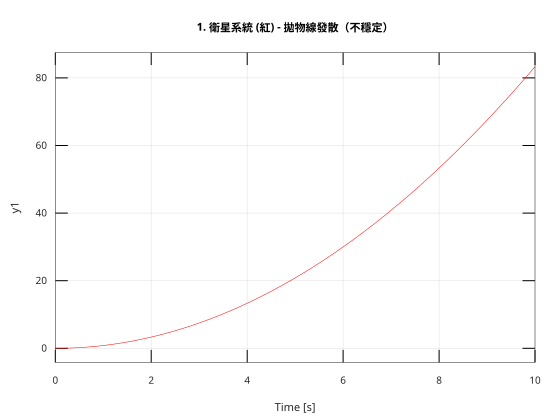

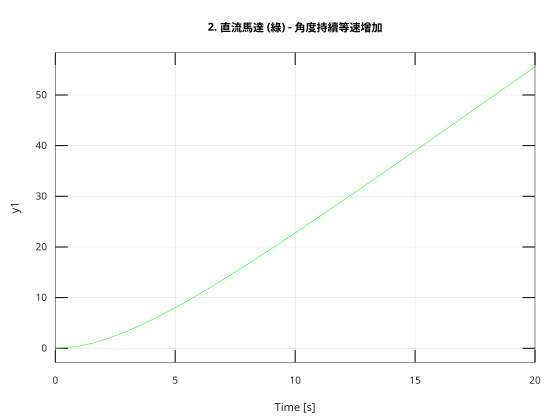

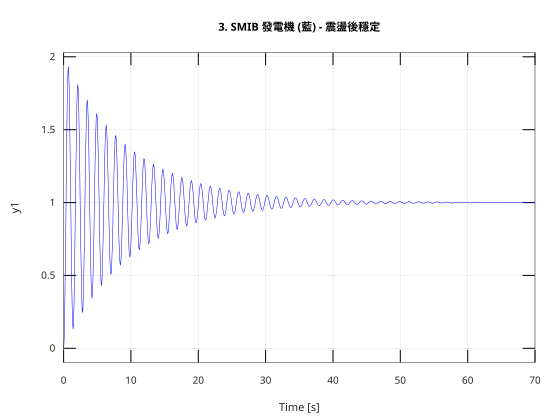

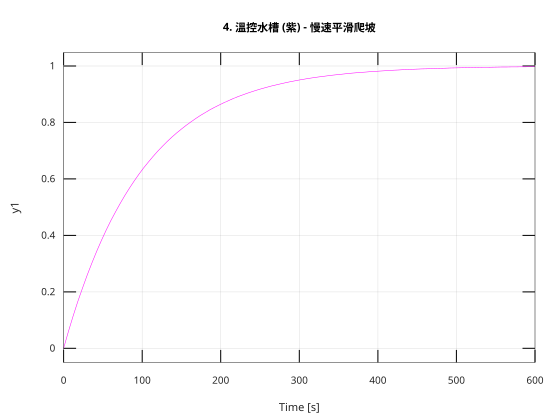

In [31]:
%% 四個獨立視窗：分別看各系統的階躍響應形狀

figure(1);
step(Gp_sat, 'r');
title('1. 衛星系統 (紅) - 拋物線發散（不穩定）');
grid on;

figure(2);
step(sys_motor, 'g');
title('2. 直流馬達 (綠) - 角度持續等速增加');
grid on;

figure(3);
step(Gp_smib, 'b');
title('3. SMIB 發電機 (藍) - 震盪後穩定');
grid on;

figure(4);
step(Gp_temp, 'm');
title('4. 溫控水槽 (紫) - 慢速平滑爬坡');
grid on;

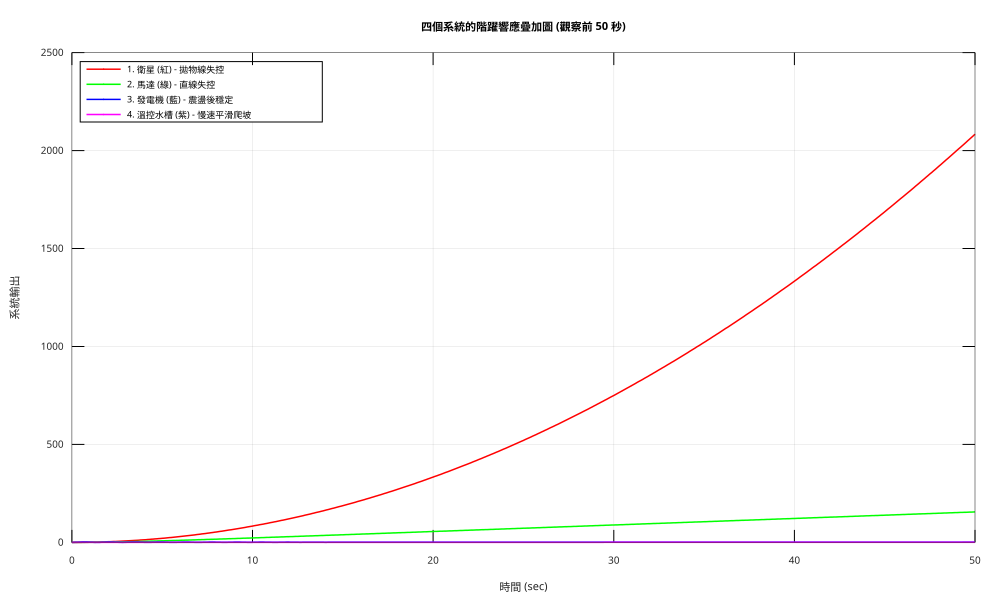

In [32]:
%% 一張疊加比較圖：統一時間軸方便直接比較四種動態行為
figure('Name', '四系統疊加比較圖', 'Position', [100, 100, 1000, 600]);
t = 0:0.1:50;   % 統一時間軸，觀察前 50 秒

[y_sat, t_sat]     = step(Gp_sat, t);
[y_motor, t_motor] = step(sys_motor, t);
[y_smib, t_smib]   = step(Gp_smib, t);
[y_temp, t_temp]   = step(Gp_temp, t);

plot(t_sat, y_sat, 'r', 'LineWidth', 1.5); hold on;
plot(t_motor, y_motor, 'g', 'LineWidth', 1.5);
plot(t_smib, y_smib, 'b', 'LineWidth', 1.5);
plot(t_temp, y_temp, 'm', 'LineWidth', 1.5);
grid on;

title('四個系統的階躍響應疊加圖 (觀察前 50 秒)');
xlabel('時間 (sec)');
ylabel('系統輸出');
legend('1. 衛星 (紅) - 拋物線失控', ...
       '2. 馬達 (綠) - 直線失控', ...
       '3. 發電機 (藍) - 震盪後穩定', ...
       '4. 溫控水槽 (紫) - 慢速平滑爬坡', ...
       'Location', 'northwest');

**結果解讀**：四條曲線清楚對比出四種完全不同的動態「性格」——

- **衛星（紅）**：$1/(Js^2)$ 有雙重積分極點在原點，階躍輸入下輸出呈拋物線持續發散，代表這是不穩定系統，沒有回授控制的話角度會一直增加下去。
- **馬達（綠）**：積分＋一階的結構，短時間內類似一階系統爬升，但因為含有一個積分極點，長時間後角度會持續等速增加（因為階躍轉矩輸入下轉速會趨於定值，角度是轉速的積分）。
- **發電機／SMIB（藍）**：穩定的二階系統，會先震盪一陣子才收斂到穩態值 1（因為 $k/k=1$）。
- **溫控水槽（紫）**：穩定的一階系統，平滑爬升趨近穩態值，沒有任何震盪。

這正是本章反覆強調的重點：**同樣是物理系統，只要受控體的動態結構不同（是否有積分器、是否有阻尼），開迴路響應就會有本質上的差異**，這也是為什麼控制系統設計必須先老老實實把 $G_p(s)$ 推導出來，而不能直接套用同一套控制器設計方式。

---

## 十、標準負回授迴路示範：`feedback()` 函數

回顧第三節的標準負回授公式：

$$
\frac{C(s)}{R(s)} = \frac{G_c(s)G_p(s)}{1+G_c(s)G_p(s)H(s)}
$$

對 SMIB 系統加上一個最簡單的比例控制器 $C(s)=K_c$（即 $G_c(s)=K_c$），並假設回授路徑為單位回授（$H(s)=1$，感測器直接把輸出原封不動送回來比較），觀察加上回授控制後暫態響應如何改變。


Transfer function 'sys_closed' from input 'u1' to output ...

               20         
 y1:  --------------------
      0.5 s^2 + 0.1 s + 30

Continuous-time model.


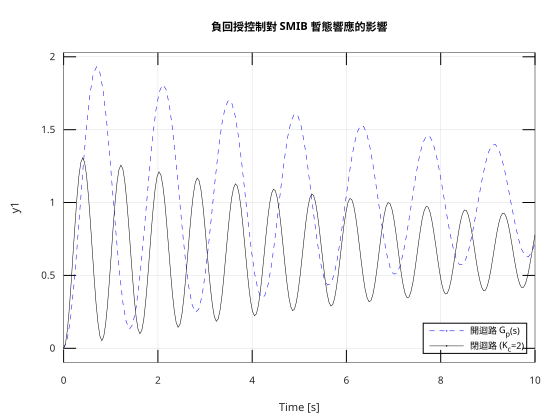

In [36]:
%% 對 SMIB 系統套用比例控制器，示範 feedback() 函數
Kc = 2;                                % 比例控制器增益，對應 Fig. 1-13 的 C(s)
Gc = tf(Kc, 1);                        % 建立控制器 C(s) = Kc（純增益，分母為常數 1）
sys_closed = feedback(Gc*Gp_smib, 1);  % 負回授：Gc*Gp / (1 + Gc*Gp*1)
sys_closed

figure('Name', 'SMIB 開迴路 vs 閉迴路比較');
step(Gp_smib, 'b--', sys_closed, 'k', 10);
legend('開迴路 G_p(s)', ['閉迴路 (K_c=' num2str(Kc) ')'], 'Location', 'southeast');
title('負回授控制對 SMIB 暫態響應的影響');
grid on;

**函數介紹：`feedback(sys1, sys2)`**——計算負回授連接後的閉迴路轉移函數。`sys1` 是**前向路徑**（forward path，即 $G_c(s)G_p(s)$，控制器串聯受控體），`sys2` 是**回授路徑**（feedback path，即 $H(s)$）。回傳結果就是：

$$
\text{feedback(sys1, sys2)} = \frac{\text{sys1}}{1+\text{sys1}\cdot\text{sys2}}
$$

當 `sys2` 省略不寫（如 `feedback(sys1, 1)` 或直接 `feedback(sys1)`）時，代表**單位回授**（$H(s)=1$）——這是最常見的情況，因為理想上我們希望感測器把輸出「原封不動」地量回來比較。

**數學 ↔ MATLAB 對照**：

| 數學 | MATLAB |
|---|---|
| $G_c(s)G_p(s)$（前向路徑） | `Gc*Gp_smib` |
| $H(s)=1$（單位回授路徑） | `feedback(..., 1)` 的第二個參數 `1` |
| $\dfrac{G_cG_p}{1+G_cG_pH}$ | `feedback(Gc*Gp_smib, 1)` |

**結果解讀**：閉迴路響應（黑線）與開迴路響應（藍虛線）相比，通常會有不同的穩態值、上升速度與震盪程度——這就是「控制器設計」實際發揮作用的地方：透過選擇合適的 $K_c$（或更複雜的控制器結構），可以調整暫態響應以滿足第三節提到的設計準則。控制器的系統化設計方法是第 8、9、11 章的主題，這裡只是先用最簡單的比例控制器，讓你直觀看到「回授」這個動作本身對系統行為的影響。

---

## 十一、本章 MATLAB / Octave 函數總整理

| 函數 | 功能 | 對應數學運算 |
|---|---|---|
| `tf(num, den)` | 建立轉移函數模型 | $G(s)=\dfrac{\text{num}(s)}{\text{den}(s)}$，係數向量由高次到低次排列 |
| `ss(A,B,C,D)` | 建立狀態空間模型 | $\dot x=Ax+Bu,\ y=Cx+Du$ |
| `series(sys1,sys2)` | 兩系統串聯 | $G_1(s)G_2(s)$（SISO 系統下等同於 `*`） |
| `parallel(sys1,sys2)` | 兩系統並聯 | $G_1(s)+G_2(s)$（SISO 系統下等同於 `+`） |
| `feedback(sys1,sys2)` | 負回授連接 | $\dfrac{\text{sys1}}{1+\text{sys1}\cdot\text{sys2}}$ |
| `step(sys)` | 單位階躍響應模擬 | 輸入 $u(t)=1\ (t\ge0)$ 下的輸出 $y(t)$ |
| `pole(sys)` | 求轉移函數的極點 | 分母多項式 $=0$ 的根 |
| `plot(x,y)` | 繪製 x-y 座標圖 | — |
| `grid on` / `hold on` | 加上格線 / 疊加繪圖 | — |
| `title()`, `xlabel()`, `ylabel()`, `legend()` | 圖表標題、座標軸標籤、圖例 | — |

完整理論推導與所有符號定義請見 `chp1.md`；純程式碼精簡版請見 `chp1.m`。